In [33]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\deeks\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [34]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\deeks\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [35]:
pip uninstall scikit-learn imbalanced-learn -y

Found existing installation: scikit-learn 1.9.0
Uninstalling scikit-learn-1.9.0:
  Successfully uninstalled scikit-learn-1.9.0
Found existing installation: imbalanced-learn 0.14.2
Uninstalling imbalanced-learn-0.14.2:
  Successfully uninstalled imbalanced-learn-0.14.2
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


In [36]:
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached scikit_learn-1.9.0-cp311-cp311-win_amd64.whl (8.3 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\deeks\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import RandomOverSampler

In [38]:
path = kagglehub.dataset_download("jackksoncsie/spam-email-dataset")

print(path)

C:\Users\deeks\.cache\kagglehub\datasets\jackksoncsie\spam-email-dataset\versions\1


In [39]:
import os
os.listdir(path)

['emails.csv']

In [40]:
df = pd.read_csv(path + "/emails.csv")

In [41]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 8.6 MB


In [43]:
df.shape

(5728, 2)

In [44]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [45]:
df = df.dropna()

In [46]:
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

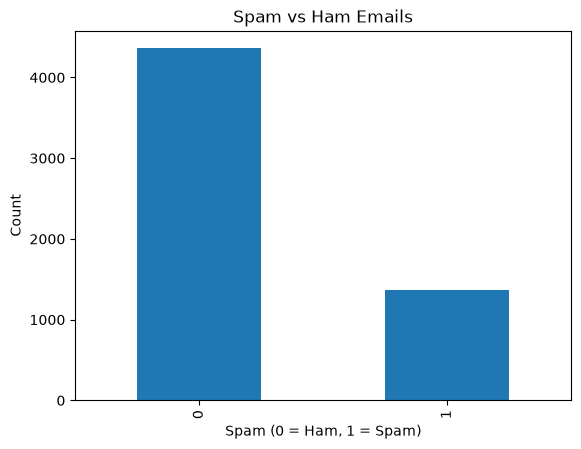

In [47]:
df['spam'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Emails")
plt.xlabel("Spam (0 = Ham, 1 = Spam)")
plt.ylabel("Count")
plt.show()

In [48]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['text'] = df['text'].apply(clean_text)

In [49]:
X = df['text']
y = df['spam']

In [50]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [52]:
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

In [53]:
print(pd.Series(y_train).value_counts())

spam
0    3504
1    3504
Name: count, dtype: int64


In [54]:
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3504.,3504.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 33406)","[[5.03,1.04,0. ,...,0. ,0.19,0. ], [0. ,0. ,0. ,...,0.09,0. ,1.47]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 33406)","[[ -9.15,-10.23,-10.95,...,-10.95,-10.78,-10.95], [-10.94,-10.94,-10.94,...,-10.86,-10.94,-10.04]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,33406


In [55]:
y_pred = model.predict(X_test)

In [56]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.987783595113438


In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       856
           1       0.98      0.97      0.98       290

    accuracy                           0.99      1146
   macro avg       0.99      0.98      0.98      1146
weighted avg       0.99      0.99      0.99      1146



In [58]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[851   5]
 [  9 281]]


In [59]:
email = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize."
]

email_vector = vectorizer.transform(email)

prediction = model.predict(email_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Spam Email


In [60]:
email = [
    "Hi team, please attend today's project meeting at 2 PM."
]

email_vector = vectorizer.transform(email)

prediction = model.predict(email_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Not Spam


In [61]:
print("========== Spam Analysis Report ==========")
print("Total Emails :", len(df))
print("Spam Emails :", (df['spam'] == 1).sum())
print("Ham Emails :", (df['spam'] == 0).sum())
print("Model Accuracy :", round(accuracy * 100, 2), "%")

========== Spam Analysis Report ==========
Total Emails : 5728
Spam Emails : 1368
Ham Emails : 4360
Model Accuracy : 98.78 %
